# Tarea de Programación: Un Asistente de Diagnóstico de Neumonía

¡Felicidades por desarrollar un sólido conjunto de habilidades en PyTorch y Lightning! Has aprendido a construir redes neuronales y a optimizar los flujos de trabajo de entrenamiento. Esta tarea es tu oportunidad para canalizar esa experiencia en un proyecto con relevancia en el mundo real.

El verdadero poder de la inteligencia artificial se demuestra cuando se aplica para resolver problemas complejos y significativos. En esta tarea, comenzarás tu camino en el impactante campo de la IA médica construyendo una herramienta para asistir a los médicos en el diagnóstico de la neumonía. Tu misión es diseñar el motor central de aprendizaje profundo para un asistente de diagnóstico potenciado por IA. Esta es una aplicación directa de las habilidades de nivel profesional que has estado desarrollando, desafiándote a construir una solución que no solo sea precisa, sino también robusta y bien estructurada.

A lo largo de esta tarea de programación, tú vas a:

* Ensamblar un `LightningDataModule` para crear un pipeline de datos limpio y reutilizable.
* Construir un `LightningModule` para encapsular tu modelo, la función de pérdida y la lógica de entrenamiento.
* Configurar un `Trainer` de Lightning con callbacks para ejecutar un bucle de entrenamiento eficiente.
* Evaluar el rendimiento de tu modelo para comprender sus capacidades predictivas.


Desarrollarás un modelo que puede analizar imágenes de radiografías de tórax y clasificarlas como **Normal**, **Neumonía Bacteriana** o **Neumonía Viral**. Esta clasificación es una tarea esencial, ya que un diagnóstico rápido y preciso puede conducir a mejores resultados para los pacientes.

---
<a name='submission'></a>

<h4 style="color:green; font-weight:bold;">TIPS FOR SUCCESSFUL GRADING OF YOUR ASSIGNMENT:</h4>

* All cells are frozen except for the ones where you need to submit your solutions or when explicitly mentioned you can interact with it.

* In each exercise cell, look for comments `### START CODE HERE ###` and `### END CODE HERE ###`. These show you where to write the solution code. **Do not add or change any code that is outside these comments**.

* You can add new cells to experiment but these will be omitted by the grader, so don't rely on newly created cells to host your solution code, use the provided places for this.

* Avoid using global variables unless you absolutely have to. The grader tests your code in an isolated environment without running all cells from the top. As a result, global variables may be unavailable when scoring your submission. Global variables that are meant to be used will be defined in UPPERCASE.

* To submit your notebook for grading, first save it by clicking the 💾 icon on the top left of the page and then click on the `Submit assignment` button on the top right of the page.
---

## Table of Contents
- [Imports](#0)
- [1 - Chest X-Ray Images](#1)
    - [1.1 - Dataset Preparation](#1-1)
    - [1.2 - Data Structure](#1-2)
    - [1.3 - The Visual Challenge: Differentiating Pneumonia Types](#1-3)
- [2 - Building the DataModule](#2)
    - [2.1 - Utilities for the DataModule](#2-1)
    - [2.2 - Assembling the ChestXRayDataModule](#2-2)
        - **[Exercise 1 - ChestXRayDataModule](#ex-1)**
- [3 - Building the LightningModule](#3)
    - [3.1 - Utilities for the LightningModule](#3-1)
    - [3.2 - Assembling the ChestXRayClassifier](#3-2)
        - **[Exercise 2 - ChestXRayClassifier](#ex-2)**
- [4 - Training the Model](#4)
    - [4.1 - Configuring Early Stopping](#4-1)
        - **[Exercise 3 - early_stopping](#ex-3)**
    - [4.2 - Configuring the Trainer](#4-2)
        - **[Exercise 4 - run_training](#ex-4)**
    - [4.3 - Training Your Diagnostic Assistant](#4-3)
- [5 - Evaluating Model Performance](#5)
    - [5.1 - Confusion Matrix and Per-Class Accuracy](#5-1)
    - [5.2 - Visualizing Predictions](#5-2)
    - [5.3 - A True Test](#5-3)

<a name='0'></a>
## Imports

In [1]:
import sys
import warnings

# Redirect stderr to a black hole to catch other potential messages
class BlackHole:
    def write(self, message):
        pass
    def flush(self):
        pass
sys.stderr = BlackHole()

# Ignore Python-level UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import os

import lightning.pytorch as pl
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from lightning.pytorch.callbacks import EarlyStopping
from torch.utils.data import DataLoader
from torchmetrics.classification import Accuracy
from torchvision import datasets, transforms
from torchvision import models as tv_models

torch.set_float32_matmul_precision('medium')

In [3]:
import matplotlib.pyplot as plt

import helper_utils
import unittests

<a name='1'></a>
## 1 - Imágenes de radiografía de tórax (Chest X-Ray Images)

Un modelo de IA médica eficaz se construye sobre una base de datos de alta calidad y relevancia. Para tu tarea, trabajarás con el [conjunto de datos de Imágenes de Radiografías de Tórax (Neumonía)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia), una valiosa colección de imágenes médicas. Este conjunto de datos consiste en radiografías de tórax obtenidas de estudios retrospectivos de pacientes pediátricos de uno a cinco años en el Centro Médico de Mujeres y Niños de Guangzhou. Para garantizar la calidad del diagnóstico, cada imagen fue evaluada y calificada por dos expertos médicos antes de su inclusión.

<a name='1-1'></a>
### 1.1 - Preparación del conjunto de datos

Para adaptar los datos a tu herramienta de diagnóstico, se realizaron algunas modificaciones importantes. El conjunto de datos original estaba organizado en las carpetas `train`, `test` y `val`. Para simplificar el proceso de evaluación, los conjuntos `test` y `val` se combinaron en un único conjunto de validación para tu uso.

Más importante aún, esta tarea te presenta un problema multiclase con matices. El conjunto de datos original solo identificaba las imágenes como `NORMAL` o `PNEUMONIA`. En la versión que utilizarás, la clase `PNEUMONIA` se ha dividido en dos categorías distintas: `BACTERIAL_PNEUMONIA` (Neumonía Bacteriana) y `VIRAL_PNEUMONIA` (Neumonía Viral). Este cambio proporciona una tarea de diagnóstico más detallada, permitiendo que tu modelo aprenda las sutiles diferencias entre los dos tipos de infección.



Finalmente, prevenir el sesgo del modelo es una parte esencial de la construcción de una herramienta médica justa y confiable. Por esa razón, el conjunto de datos fue **balanceado**. Se eliminaron aleatoriamente imágenes de las clases más frecuentes hasta que cada clase en los conjuntos de entrenamiento y validación contuviera exactamente el mismo número de imágenes.

* Comienza definiendo la ruta al conjunto de datos.

In [4]:
data_dir = "./chest_xray/"

<a name='1-2'></a>
### 1.2 - Estructura de Datos

Los datos están organizados en los directorios `train` y `val`, con subdirectorios para cada una de las tres clases. Verás la siguiente estructura:

```
./chest_xray/
│
├── train/
│   ├── NORMAL/
│   │   ├── IM-0001-0001.jpeg
│   │   └── ...
│   │
│   ├── BACTERIAL_PNEUMONIA/
│   │   ├── person1_bacteria_1.jpeg
│   │   └── ...
│   │
│   └── VIRAL_PNEUMONIA/
│       ├── person140_virus_284.jpeg
│       └── ...
│
└── val/
    ├── NORMAL/
    │   ├── IM-0001-0001.jpeg
    │   └── ...
    │
    ├── BACTERIAL_PNEUMONIA/
    │   ├── person1946_bacteria_4874.jpeg
    │   └── ...
    │
    └── VIRAL_PNEUMONIA/
        ├── person16_virus_44.jpeg
        └── ...
```

* Ejecuta la celda de abajo para confirmar que la distribución de imágenes en todas las clases, tanto en el conjunto de entrenamiento como en el de validación, está equilibrada.


In [6]:
helper_utils.display_dataset_count(data_dir)

--- Train Set ---
  - BACTERIAL_PNEUMONIA      : 1339 images
  - NORMAL                   : 1338 images
  - VIRAL_PNEUMONIA          : 1338 images
——————————————————————————————————————————————————
  Total:                      4015 images

--- Val Set ---
  - BACTERIAL_PNEUMONIA      : 148 images
  - NORMAL                   : 148 images
  - VIRAL_PNEUMONIA          : 148 images
——————————————————————————————————————————————————
  Total:                       444 images



<a name='1-3'></a>
### 1.3 - El Desafío Visual: Diferenciando los Tipos de Neumonía

Para apreciar el desafío que tu modelo está asumiendo, es útil reconocer los patrones visuales generales asociados con cada clase. Piensa en una radiografía de tórax como una imagen donde los materiales densos como los huesos aparecen de color blanco, y los espacios llenos de aire, como los pulmones sanos, se ven oscuros. Una infección puede hacer que partes de los pulmones se llenen de líquido, haciendo que se vean borrosas o blancas.

Ten en cuenta que estas son observaciones simplificadas para esta tarea; un diagnóstico definitivo requiere la habilidad de un experto médico capacitado.

* Una radiografía de tórax **Normal** generalmente muestra pulmones despejados y oscuros, lo que indica que están correctamente llenos de aire. Por lo general, se pueden ver los contornos nítidos del corazón, el diafragma y la caja torácica.

* La **Neumonía Bacteriana** a menudo se presenta como un parche denso, blanco o turbio que está más localizado en un área específica del pulmón, a veces llamada "consolidación".

* En comparación, la **Neumonía Viral** tiende a verse más extendida y dispersa. El patrón suele ser una blancura más difusa, borrosa o veteada que se puede ver en ambos pulmones.

Ejecuta la celda de abajo para visualizar algunos ejemplos aleatorios del conjunto de datos de entrenamiento y observar estos patrones por ti mismo.

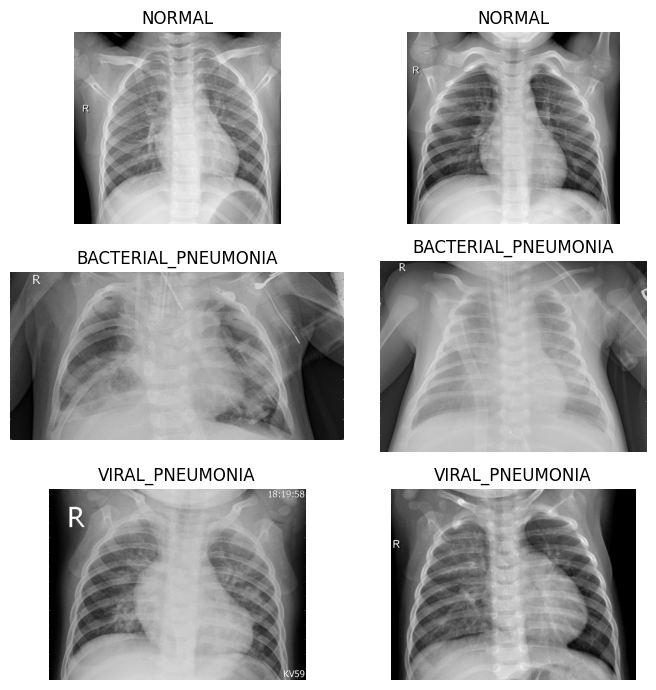

In [7]:
# Muestra una cuadrícula de imágenes aleatorias del conjunto de entrenamiento para visualizar los datos.
helper_utils.display_random_images(data_dir + "train")

<a name='2'></a>
## 2 - Construcción del `DataModule`

Ya has visto cómo Lightning simplifica el proceso de manejo de datos. Ahora utilizarás su `DataModule` para gestionar todo lo relacionado con el conjunto de datos de esta tarea. Tu primer ejercicio consiste en ensamblar el `ChestXRayDataModule`.

Antes de construir el módulo, primero definirás los componentes esenciales, o "utilidades", que utilizará tu `DataModule`.

<a name='2-1'></a>
### 2.1 - Utilidades para el `DataModule`

Las celdas de código a continuación contienen los flujos de transformación (pipelines) preescritos y las funciones auxiliares necesarias para tu `DataModule`. Revisa cada una cuidadosamente para entender su función.

* `TRAIN_TRANSFORM` y `VAL_TRANSFORM`: Estos son los flujos de transformación de `torchvision`. El pipeline de entrenamiento incluye aumentación de datos (data augmentation) para ayudar a tu modelo a generalizar, mientras que el pipeline de validación realiza solo el preprocesamiento necesario para la evaluación.

In [8]:
# Define la serie de transformaciones que se aplicarán a las imágenes de entrenamiento.
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Realiza una transformación afín aleatoria: desplaza y escala la imagen.
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    # Normaliza la imagen del tensor con una media y una desviación estándar 
    # precalculadas de este conjunto de datos.
    transforms.Normalize([0.482, 0.482, 0.482], [0.222, 0.222, 0.222])
])

# Define las transformaciones para las imágenes de validación.
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Normaliza la imagen del tensor con una media y una desviación estándar 
    # precalculadas de este conjunto de datos.
    transforms.Normalize([0.482, 0.482, 0.482], [0.222, 0.222, 0.222])
])

* `create_datasets(…)`: Esta función toma las rutas de los archivos y las transformaciones como entrada, y devuelve los conjuntos de datos `ImageFolder` de entrenamiento y validación inicializados.



In [9]:
def create_datasets(train_path, val_path, train_transform, val_transform):
    """
    Crea y devuelve los conjuntos de datos necesarios para el entrenamiento y la validación.

    Argumentos:
        train_path (str): La ruta del archivo a las imágenes de entrenamiento.
        val_path (str): La ruta del archivo a las imágenes de validación.
        train_transform (callable): Transformaciones para aplicar a los datos de entrenamiento.
        val_transform (callable): Transformaciones para aplicar a los datos de validación.

    Devuelve:
        Una tupla que contiene el train_dataset (dataset de entrenamiento) y el val_dataset (dataset de validación).
    """
    # Crea los conjuntos de datos de entrenamiento y validación a partir de las carpetas de imágenes.
    train_dataset = datasets.ImageFolder(train_path, train_transform)
    val_dataset = datasets.ImageFolder(val_path, val_transform)

    return train_dataset, val_dataset

* `load_dataloader(…)`: Esta función toma los conjuntos de datos y otros parámetros para crear y devolver un `DataLoader`, ya sea de entrenamiento o de validación.

In [10]:
def load_dataloader(train_dataset, val_dataset, batch_size, is_train_loader):
    """
    Crea y devuelve un DataLoader de entrenamiento o de validación.

    Argumentos:
        train_dataset (Dataset): El conjunto de datos para el cargador de entrenamiento.
        val_dataset (Dataset): El conjunto de datos para el cargador de validación.
        batch_size (int): El número de muestras por lote (batch) a cargar.
        is_train_loader (bool): Una bandera para determinar qué cargador crear.
                                Si es True, crea el cargador de entrenamiento.
                                Si es False, crea el cargador de validación.

    Devuelve:
        DataLoader: El DataLoader de PyTorch configurado.
    """
    # Verifica la bandera para determinar si se crea un cargador de entrenamiento o de validación.
    if is_train_loader == True:
        # Crea el DataLoader de entrenamiento.
        loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
    else:
        # Crea el DataLoader de validación.
        loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )
        
    return loader

<a name='2-2'></a>
### 2.2 - Ensamblando el `ChestXRayDataModule`

Ya has definido todas las utilidades necesarias para tu pipeline de datos. Ahora te encuentras en la etapa final de ensamblaje, donde unirás estos componentes dentro de un `LightningDataModule`.



El `DataModule` actúa como la columna vertebral organizativa de todo tu flujo de datos. Encapsula toda la lógica relacionada con los datos —desde la carga y división hasta la transformación y el procesamiento por lotes— en una sola clase reutilizable. Esta práctica mantiene limpio el código principal de tu modelo y garantiza que el manejo de datos sea reproducible, lo cual es esencial para cualquier aplicación de IA médica.

<a name='ex-1'></a>
### Ejercicio 1 - ChestXRayDataModule

Tu ejercicio consiste en completar el `ChestXRayDataModule` utilizando las utilidades que acabas de revisar.

**Tu tarea**:

* **Dentro del método `__init__`**: 
>    * Este es el método de configuración de tu `DataModule`. Debes almacenar el `data_dir` y el `batch_size` que se reciben.
>    * También debes asignar los pipelines de transformación predefinidos, `TRAIN_TRANSFORM` y `VAL_TRANSFORM`, a atributos de instancia para que otros métodos de la clase puedan acceder a ellos.

* **Dentro del método `setup`**: 
>    * Este método es responsable de crear los conjuntos de datos. Usarás la función auxiliar `create_datasets` para inicializar `self.train_dataset` y `self.val_dataset`.
>    * Asegúrate de pasar los argumentos correctos a la función, incluyendo las rutas y las transformaciones que almacenaste anteriormente.

* **Dentro de los métodos `train_dataloader` y `val_dataloader`**: 
>    * Estos métodos crean los cargadores de datos (data loaders) que enviarán lotes de datos a tu modelo.
>    * Deberás llamar a la función auxiliar `load_dataloader` en cada método. Presta mucha atención al flag `is_train_loader` para asegurarte de crear el tipo correcto de cargador (uno para entrenamiento y otro para validación).

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te has atascado)</font></b></summary>

Si tienes dificultades, aquí tienes un desglose más detallado.

**Para el método `__init__`**:

* Simplemente estás guardando los argumentos pasados al constructor.
* Por ejemplo, la primera línea será `self.data_dir = data_dir`. Sigue este mismo patrón para `batch_size`, `train_transform` y `val_transform`.

**Para el método `setup`**:

* Debes llamar a la función `create_datasets` y asignar sus dos salidas a `self.train_dataset` y `self.val_dataset`.
* La llamada a la función debería verse así:
    > `self.train_dataset, self.val_dataset = llamar a create_datasets(usando train_path, val_path, self.train_transform y self.val_transform como argumentos)`

**Para el método `train_dataloader`**:

* Llama a la función `load_dataloader`. La clave es indicarle que quieres un cargador de *entrenamiento*.
* La llamada se verá así:
    > `train_loader = load_dataloader(con self.train_dataset, self.val_dataset, self.batch_size y el flag is_train_loader configurado en True)`

**Para el método `val_dataloader`**:

* Esto es muy similar al cargador de entrenamiento, pero debes indicar que quieres un cargador de *validación*.
* La llamada se verá así:
    > `val_loader = load_dataloader(con self.train_dataset, self.val_dataset, self.batch_size y el flag is_train_loader configurado en False)`

</details>

In [11]:
# CLASE CALIFICADA: ChestXRayDataModule

class ChestXRayDataModule(pl.LightningDataModule):
    """
    Un LightningDataModule encapsula todos los pasos involucrados en la preparación de datos
    para un modelo de PyTorch.
    """

    def __init__(self, data_dir, batch_size=64):
        """
        Inicializa el DataModule y almacena los parámetros clave.

        Argumentos:
            data_dir (str): Directorio donde se almacenan los datos.
            batch_size (int): Número de muestras por lote en el DataLoader.
        """
        super().__init__()
        
        ### START CODE HERE ###
        
        # Almacena los argumentos del constructor como atributos de instancia.
        self.data_dir = data_dir
        self.batch_size = batch_size
        
        # Asigna las transformaciones definidas globalmente a esta instancia.
        self.train_transform = TRAIN_TRANSFORM
        self.val_transform = VAL_TRANSFORM
        
        ### END CODE HERE ###
        
        # NO ELIMINES NINGUNO DE ESTOS ESPACIOS EN BLANCO (PLACEHOLDERS)
        # Espacios para los conjuntos de datos, que se asignarán en setup().
        self.train_dataset = None
        self.val_dataset = None

    def setup(self, stage=None):
        """
        Asigna los conjuntos de datos de entrenamiento y validación.

        Argumentos:
        stage (str, opcional): La etapa del entrenamiento (por ejemplo, 'fit', 'test').
                               El Trainer de Lightning requiere este argumento, pero no se
                               utiliza en esta implementación ya que la lógica de configuración 
                               es la misma para todas las etapas. Por defecto es None.
        """
        # Construye las rutas completas a las carpetas de imágenes de entrenamiento y validación.
        train_path = os.path.join(self.data_dir, "train")
        val_path = os.path.join(self.data_dir, "val")
        
        ### START CODE HERE ###
        
        # Llama a la función auxiliar `create_datasets` con los argumentos correctos
        # para inicializar self.train_dataset y self.val_dataset.
        self.train_dataset, self.val_dataset = create_datasets(
            train_path,
            val_path,
            self.train_transform,
            self.val_transform
        ) 
            
        ### END CODE HERE ###

    def train_dataloader(self):
        """Devuelve el DataLoader para el conjunto de entrenamiento."""
        
        ### START CODE HERE ###
        
        # Llama a la función auxiliar `load_dataloader` para crear el
        # cargador de entrenamiento.
        train_loader = load_dataloader(
            self.train_dataset,
            self.val_dataset,
            self.batch_size,
            True
        ) 
        
        ### END CODE HERE ###
        
        return train_loader

    def val_dataloader(self):
        """Devuelve el DataLoader para el conjunto de validación."""
        
        ### START CODE HERE ###
        
        # Llama a la función auxiliar `load_dataloader` para crear el
        # cargador de validación.
        val_loader = load_dataloader(
            self.train_dataset,
            self.val_dataset,
            self.batch_size,
            False
        ) 
        
        ### END CODE HERE ###
        
        return val_loader

In [12]:
# Instancia el DataModule para la verificación.
dm_verify = ChestXRayDataModule(data_dir=data_dir, batch_size=8)
# Configura los conjuntos de datos.
dm_verify.setup()
train_loader_verify = dm_verify.train_dataloader()
val_loader_verify = dm_verify.val_dataloader()

# --- Verificar el Conjunto de Entrenamiento ---
print("--- Conjunto de Entrenamiento ---")
print(f"Total de muestras en el dataset de entrenamiento:    {len(dm_verify.train_dataset)}")
print(f"Tamaño del lote (batch size) del DataLoader:         {train_loader_verify.batch_size}")
print(f"Longitud del DataLoader (número de lotes):           {len(train_loader_verify)}")

# --- Verificar el Conjunto de Validación ---
print("\n--- Conjunto de Validación ---")
print(f"Total de muestras en el dataset de validación:       {len(dm_verify.val_dataset)}")
print(f"Tamaño del lote (batch size) del DataLoader:         {val_loader_verify.batch_size}")
print(f"Longitud del DataLoader (número de lotes):           {len(val_loader_verify)}")

--- Conjunto de Entrenamiento ---
Total de muestras en el dataset de entrenamiento:    4015
Tamaño del lote (batch size) del DataLoader:         8
Longitud del DataLoader (número de lotes):           502

--- Conjunto de Validación ---
Total de muestras en el dataset de validación:       444
Tamaño del lote (batch size) del DataLoader:         8
Longitud del DataLoader (número de lotes):           56


#### Expected Output:

```
--- Training Set ---
Total samples in the training dataset:    4014
DataLoader batch size:                    8
DataLoader length (number of batches):    502

--- Validation Set ---
Total samples in the validation dataset:  444
DataLoader batch size:                    8
DataLoader length (number of batches):    56
```

In [13]:
# Test your code!
unittests.exercise_1(ChestXRayDataModule)

 All tests passed!


<a name='3'></a>
## 3 - Construcción del `LightningModule`

Con el pipeline de datos completado, tu siguiente tarea es construir el `ChestXRayClassifier`, que es un `LightningModule`. Esta clase es el núcleo de tu modelo de IA; organiza todos los componentes esenciales para el entrenamiento, incluyendo la arquitectura del modelo, la función de pérdida y los optimizadores, en un sistema único y autónomo.

Al igual que antes, primero revisarás las utilidades preescritas que tu `LightningModule` utilizará para funcionar.

<a name='3-1'></a>
### 3.1 - Utilidades para el `LightningModule`

Las funciones auxiliares a continuación están diseñadas para manejar la inicialización del modelo y la configuración del optimizador. Revisa cada una para entender su rol específico antes de usarlas en el ejercicio principal.

* `load_resnet18(…)`: Esta función inicializa un modelo ResNet-18 y lo prepara para el aprendizaje por transferencia (transfer learning). Reemplaza la capa de clasificación final por una nueva adecuada para tu problema de tres clases y congela todas las demás capas. Esto garantiza que solo estés entrenando el nuevo "cabezal" sobre las potentes características preentrenadas.

In [14]:
def load_resnet18(num_classes, weights_path):
    """
    Inicializa un modelo ResNet-18, carga los pesos y lo configura
    para aprendizaje por transferencia (extracción de características).

    Argumentos:
        num_classes (int): El número de clases de salida para el nuevo cabezal clasificador.
        weights_path (str): La ruta del archivo de los pesos del modelo .pth guardados.

    Devuelve:
        Un modelo de PyTorch (ResNet-18) donde todas las capas están congeladas excepto
        el cabezal clasificador final.
    """
    # Inicializa un modelo ResNet-18 sin pesos pre-entrenados.
    model = tv_models.resnet18(weights=None)

    # Reemplaza el cabezal clasificador para que coincida con el número de clases de la nueva tarea.
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    # Carga el diccionario de estados (pesos) desde el archivo local.
    state_dict = torch.load(weights_path, map_location=torch.device('cpu'))
    model.load_state_dict(state_dict)

    # Congela todos los parámetros del modelo.
    for param in model.parameters():
        param.requires_grad = False

    # Descongela ÚNICAMENTE los parámetros del nuevo cabezal clasificador.
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

* `define_optimizer_and_scheduler(…)`: Esta función devuelve el optimizador `AdamW` y un programador de tasa de aprendizaje (learning rate scheduler) `ReduceLROnPlateau`. El programador reducirá automáticamente la tasa de aprendizaje si la pérdida de validación deja de mejorar, lo cual es una técnica común para un entrenamiento eficaz.

In [15]:
def define_optimizer_and_scheduler(model, learning_rate, weight_decay):
    """
    Define el optimizador y el programador de la tasa de aprendizaje para el modelo.

    Argumentos:
        model (nn.Module): El modelo para el cual se configurará el optimizador.
                           Sus parámetros se pasarán al optimizador.
        learning_rate (float): La tasa de aprendizaje para el optimizador.
        weight_decay (float): El decaimiento de peso (penalización L2) para el optimizador.

    Devuelve:
        Una tupla que contiene el optimizador y el lr_scheduler configurados.
    """
    # Crea el optimizador.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    
    # Crea el programador de la tasa de aprendizaje (learning rate scheduler).
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=2
    )
    
    return optimizer, scheduler

<a name='3-2'></a>
### 3.2 - Ensamblando el `ChestXRayClassifier`

Has llegado al corazón de la tarea: ensamblar el `ChestXRayClassifier`. Aquí es donde definirás el sistema completo para tu modelo de diagnóstico.



El `LightningModule` es el centro de mando central de tu modelo. Reúne la arquitectura de la red neuronal (tu ResNet-18 preentrenada), la función de pérdida para medir el error, las métricas para rastrear el rendimiento y los optimizadores que impulsan el proceso de aprendizaje. Al organizar estos componentes en una sola clase, creas un sistema limpio, portátil y altamente estructurado, una marca distintiva de la ingeniería profesional de aprendizaje profundo.

<a name='ex-2'></a>
### Ejercicio 2 - ChestXRayClassifier

Tu ejercicio consiste en completar el `ChestXRayClassifier` utilizando las utilidades que acabas de revisar.

**Tu tarea**:

* **Dentro del método `__init__`**: 
>    * Este método configura los componentes principales de tu clasificador.
>    * Debes inicializar el modelo preentrenado llamando a la función auxiliar `load_resnet18`.
>    * Define la función de pérdida. Para este problema de clasificación multiclase, `nn.CrossEntropyLoss` es la elección correcta.
>    * Define la métrica de precisión utilizando `Accuracy`. Recuerda configurarla para una tarea "multiclass".

* **Dentro del método `training_step`**: 
>    * Este método define la lógica para una sola pasada hacia adelante (forward pass) y el cálculo de la pérdida durante el entrenamiento.
>    * Primero, desempaca el `batch` de entrada en imágenes y sus etiquetas correspondientes.
>    * Luego, obtén las predicciones brutas del modelo (`logits`) realizando una pasada hacia adelante con las imágenes.
>    * Finalmente, calcula la pérdida de entrenamiento comparando los logits del modelo con las etiquetas reales.

* **Dentro del método `validation_step`**: 
>    * Este método es similar a `training_step` pero se utiliza para el bucle de validación.
>    * Desempacarás el `batch`, obtendrás los `logits` y calcularás la `loss` de la misma manera.
>    * También necesitas calcular la precisión (`accuracy`) para el lote de validación utilizando la métrica que definiste en `__init__`.

* **Dentro del método `configure_optimizers`**: 
>    * Este método configura el optimizador y el programador de tasa de aprendizaje para el proceso de entrenamiento.
>    * Llamarás a la función auxiliar `define_optimizer_and_scheduler` para obtener el optimizador y el programador configurados.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te has atascado)</font></b></summary>

Si tienes dificultades, aquí tienes un desglose más detallado.

**Para el método `__init__`**:

* Para cargar el modelo, llamarás a la función auxiliar proporcionada:
    > `self.model = load_resnet18(con num_classes de self.hparams, y weights_path de self.hparams)`
* Instanciar la función de pérdida es una llamada directa sin argumentos:
    > `self.loss_fn = instanciar nn.CrossEntropyLoss()`
* Para la métrica de precisión, debes proporcionar el tipo de tarea y el número de clases:
    > `self.accuracy = instanciar Accuracy(con task configurado en "multiclass", y num_classes de self.hparams)`

**Para el método `training_step`**:

* Desempacar el lote es directo: `x, y = batch`.
* Una pasada hacia adelante se hace llamando a la instancia misma sobre el tensor de entrada: `logits = self(x)`
* Calcula la pérdida pasando las predicciones y las etiquetas reales a tu función de pérdida:
    > `loss = self.loss_fn(logits, y)`

**Para el método `validation_step`**:

* Los primeros tres pasos son idénticos al `training_step`.
* Para calcular la precisión, usarás el objeto de precisión que creaste, pasándole los mismos logits y etiquetas:
    > `acc = self.accuracy(logits, y)`

**Para el método `configure_optimizers`**:

* Debes llamar a la función auxiliar y capturar sus dos salidas.
* La llamada a la función debería verse así:
    > `optimizer, scheduler = llamar a define_optimizer_and_scheduler(pasando self.model, y el learning_rate y weight_decay de self.hparams)`

</details>

In [16]:
# CLASE CALIFICADA: ChestXRayClassifier

class ChestXRayClassifier(pl.LightningModule):
    """Un LightningModule enfocado en rastrear la pérdida y precisión de validación."""

    def __init__(self, model_weights_path, num_classes=3, learning_rate=1e-3, weight_decay=1e-2):
        """
        Inicializa el módulo ChestXRayClassifier.

        Argumentos:
            model_weights_path (str): La ruta del archivo a los pesos del modelo ResNet-18 pre-entrenado.
            num_classes (int): El número de clases para la clasificación. Por defecto es 3.
            learning_rate (float): La tasa de aprendizaje para el optimizador. Por defecto es 1e-3.
            weight_decay (float): El decaimiento de peso (penalización L2) para el optimizador. Por defecto es 1e-2.
        """
        super().__init__()
        # Guarda todos los argumentos de __init__ (model_weights_path, num_classes, etc.) en self.hparams
        # Por ejemplo, accederás a `num_classes` como `self.hparams.num_classes`
        self.save_hyperparameters()
        
        ### START CODE HERE ###

        # Llama a la función auxiliar `load_resnet18` para obtener el modelo pre-entrenado.
        self.model = load_resnet18(
            num_classes,
            model_weights_path
        ) 
        
        # Define la función de pérdida de Entropía Cruzada (Cross Entropy).
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Define la métrica de precisión usando `Accuracy`.
        # Recuerda especificar la tarea (task) y el número de clases.
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.num_classes)
        
        ### END CODE HERE ###

    def forward(self, x):
        """
        Define la pasada hacia adelante (forward pass) del modelo.

        Argumentos:
            x (torch.Tensor): El tensor de entrada de las imágenes.
        """
        return self.model(x)

    def training_step(self, batch, batch_idx=None):
        """
        Realiza un único paso de entrenamiento. El cálculo de la pérdida es necesario para la retropropagación.

        Argumentos:
            batch (tuple): Una tupla que contiene las imágenes de entrada y sus etiquetas.
            batch_idx (int): El índice del lote actual. El Trainer de Lightning requiere 
                             este argumento, pero no se utiliza en esta implementación 
                             ya que la lógica es la misma para todos los lotes.
        """
        
        ### START CODE HERE ###
        
        # Desempaca el lote en imágenes y etiquetas.
        x, y = batch
        # Realiza una pasada hacia adelante para obtener los logits del modelo.
        logits = self(x)
        # Calcula la pérdida comparando los logits con las etiquetas reales.
        loss = self.loss_fn(logits, y)
        
        ### END CODE HERE ###
        
        return loss

    def validation_step(self, batch, batch_idx=None):
        """
        Realiza un único paso de validación y registra solo la pérdida y la precisión.

        Argumentos:
            batch (tuple): Una tupla que contiene las imágenes de entrada y sus etiquetas.
            batch_idx (int): El índice del lote actual. El Trainer de Lightning requiere 
                             este argumento, pero no se utiliza en esta implementación 
                             ya que la lógica es la misma para todos los lotes.
        """
        
        ### START CODE HERE ###
        
        # Desempaca el lote en imágenes y etiquetas.
        x, y = batch
        # Realiza una pasada hacia adelante para obtener los logits del modelo.
        logits = self(x)
        # Calcula la pérdida.
        loss = self.loss_fn(logits,y)
        # Calcula la precisión.
        acc = self.accuracy(logits,y)
        
        ### END CODE HERE ###
        
        # Registra las métricas para esta época de validación y las muestra en la barra de progreso.
        self.log_dict({'val_loss': loss, 'val_acc': acc}, prog_bar=True)

    def configure_optimizers(self):
        """Configura los optimizadores y el programador de la tasa de aprendizaje."""
        
        ### START CODE HERE ###
        
        # Llama a la función auxiliar `define_optimizer_and_scheduler`.
        optimizer, scheduler = define_optimizer_and_scheduler(
            self.model,
            self.hparams.learning_rate,
            self.hparams.weight_decay
        ) 
        
        ### END CODE HERE ###
        
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}

In [17]:
# Instancia el clasificador para la verificación.
weights_path = helper_utils.setup_dummy_weights()
verify_model = ChestXRayClassifier(model_weights_path=weights_path)

# Obtiene el optimizador y el programador (scheduler).
optimizer_config = verify_model.configure_optimizers()
optimizer = optimizer_config["optimizer"]
scheduler = optimizer_config["lr_scheduler"]["scheduler"]

# --- Imprime los resultados para verificar ---
print("--- Componentes del LightningModule ---")
print(f"Arquitectura del Modelo: {verify_model.model.__class__.__name__}")
print(f"Cabezal del Clasificador:  {verify_model.model.fc}")
print(f"Función de Pérdida:        {verify_model.loss_fn.__class__.__name__}")
print(f"Métrica de Precisión:      {verify_model.accuracy.__class__.__name__}(num_classes={verify_model.accuracy.num_classes})")
print(f"Optimizador:               {optimizer.__class__.__name__}")
print(f"Programador de LR:         {scheduler.__class__.__name__}")

# Limpia los pesos de prueba (dummy weights)
helper_utils.cleanup_dummy_weights()

--- Componentes del LightningModule ---
Arquitectura del Modelo: ResNet
Cabezal del Clasificador:  Linear(in_features=512, out_features=3, bias=True)
Función de Pérdida:        CrossEntropyLoss
Métrica de Precisión:      MulticlassAccuracy(num_classes=3)
Optimizador:               AdamW
Programador de LR:         ReduceLROnPlateau


#### Expected Output

```
--- LightningModule Components ---
Model Architecture: ResNet
Classifier Head:    Linear(in_features=512, out_features=3, bias=True)
Loss Function:      CrossEntropyLoss
Accuracy Metric:    MulticlassAccuracy(num_classes=3)
Optimizer:          AdamW
LR Scheduler:       ReduceLROnPlateau
```

In [18]:
# Test your code!
unittests.exercise_2(ChestXRayClassifier)

 All tests passed!


<a name='4'></a>
## 4 - Entrenamiento del Modelo

Has preparado con éxito los datos y ensamblado el modelo. El paso final es configurar y ejecutar el proceso de entrenamiento. Para este propósito, configurarás un callback para un entrenamiento eficiente y el trainer.

<a name='4-1'></a>
### 4.1 - Configuración del Early Stopping (Parada Temprana)

Entrenar un modelo durante demasiado tiempo puede llevar al sobreajuste (overfitting), mientras que detenerlo demasiado pronto puede resultar en un modelo subentrenado. Una técnica común para encontrar el equilibrio adecuado es el **early stopping**.



El callback [EarlyStopping](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.EarlyStopping.html) de Lightning monitorea una métrica específica y detiene automáticamente el proceso de entrenamiento una vez que se alcanza un umbral de rendimiento deseado. Esto garantiza que entrenes el tiempo justo para lograr tu objetivo sin desperdiciar recursos computacionales.

<a name='ex-3'></a>
### Ejercicio 3 - early_stopping

Tu ejercicio consiste en configurar el callback `EarlyStopping` para gestionar de forma inteligente la duración de tu entrenamiento.

**Tu tarea**:

* **Instanciar el callback `EarlyStopping`**:
>
    * Debes crear una instancia de la clase `EarlyStopping` con los parámetros correctos.
>     
    * `monitor`: Especifica la métrica a seguir. Para esta tarea, monitorearás la precisión de validación, que se registra como `"val_acc"`.
>     
    * `stopping_threshold`: Establece el valor de `stop_threshold` para la métrica monitoreada. El entrenamiento se detendrá una vez que se alcance este valor.
>     
    * `patience`: Define el número de épocas que se debe esperar por una mejora en `val_acc`. Si la precisión no mejora durante este número de épocas consecutivas, el entrenamiento se detendrá. Debes configurar esto a la **mitad** del total de `num_epochs`. Recuerda, la paciencia debe ser un número **entero**.
>     
    * `mode`: Indica al callback si debe buscar un aumento o una disminución en la métrica monitoreada. Dado que una mayor precisión de validación es mejor, debes configurar esto en `"max"`.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te has atascado)</font></b></summary>

Si tienes dificultades, aquí tienes un desglose más detallado.

**Para instanciar el callback `EarlyStopping`**:

Estás completando los argumentos para una única llamada a la función. El pseudocódigo para la instanciación completa se ve así:
```
    stop = EarlyStopping(
        monitor se establece en la cadena 'val_acc',
        stopping_threshold se establece en el argumento de la función stop_threshold,
        patience se establece en la mitad de num_epochs convertido a un entero,
        mode se establece en la cadena 'max'
        )
```
</details>


In [19]:
# FUNCIÓN CALIFICADA: early_stopping

def early_stopping(num_epochs, stop_threshold):
    """
    Configura y devuelve un callback EarlyStopping de Lightning.

    Argumentos:
        num_epochs (int): El número máximo de épocas, utilizado para establecer la paciencia (patience).
        stop_threshold (float): El umbral de precisión de validación para detener el entrenamiento.

    Devuelve:
        EarlyStopping: El callback de Lightning configurado.
    """
    
    ### START CODE HERE ###
    
    # Instancia el callback EarlyStopping.
    stop = EarlyStopping(
        # Especifica la métrica a monitorear como la precisión de validación (validation accuracy).
        monitor="val_acc",
        
        # Establece el valor que la métrica monitoreada debe alcanzar para detener el entrenamiento.
        stopping_threshold=stop_threshold,
        
        # Establece la paciencia (patience) a la mitad del total de épocas. 
        # PISTA: Usa la conversión de tipos (type casting) para asegurar que el valor sea un entero.
        patience=num_epochs//2,
        
        # Establece el modo a "max" porque una precisión mayor es mejor.
        mode="max"
    ) 
    
    ### END CODE HERE ###
    
    return stop

In [20]:
# Define los parámetros de muestra para la verificación.
num_epochs_verify = 15
stop_threshold_verify = 0.90

# Llama a la función para crear el callback.
verify_callback = early_stopping(num_epochs_verify, stop_threshold_verify)

# --- Imprime los resultados para verificar ---
print("--- Configuración de EarlyStopping ---")
print(f"Métrica a Monitorear:   {verify_callback.monitor}")
print(f"Umbral de Parada:       {verify_callback.stopping_threshold}")
print(f"Paciencia (Patience):   {verify_callback.patience}")
print(f"Modo:                   {verify_callback.mode}")

--- Configuración de EarlyStopping ---
Métrica a Monitorear:   val_acc
Umbral de Parada:       0.9
Paciencia (Patience):   7
Modo:                   max


#### Expected Output:

```
--- EarlyStopping Configuration ---
Metric to Monitor:     val_acc
Stopping Threshold:    0.9
Patience:              7
Mode:                  max
```

In [21]:
# Test your code!
unittests.exercise_3(early_stopping)

 All tests passed!


<a name='4-2'></a>
### 4.2 - Configuración del Trainer

Con tu `DataModule`, `LightningModule` y el callback `EarlyStopping` listos, ahora puedes configurar el proceso de entrenamiento. El `pl.Trainer` es el motor que orquesta todo el bucle de entrenamiento, manejando automáticamente desde la aceleración de hardware hasta los callbacks.



<a name='ex-4'></a>
### Ejercicio 4 - run_training

Tu ejercicio consiste en configurar el `Trainer` de Lightning y utilizarlo para ejecutar el proceso de entrenamiento.

**Tu tarea**:

* **Instanciar el `pl.Trainer`**:
    * Debes completar la instanciación del objeto `Trainer`.
    * Establece el número máximo de épocas de entrenamiento con el valor de `num_epochs` proporcionado.
    * Habilita el **entrenamiento de precisión mixta de 16 bits** para un cálculo más rápido.
    * Pasa el `callback` al `Trainer`. Ten en cuenta que el argumento `callbacks` espera una lista de callbacks.
* **Ejecutar el entrenamiento**:
    * Después de configurar el `Trainer`, debes iniciar el bucle de entrenamiento.
    * Llama al método `.fit()` en tu instancia del trainer, pasándole el `model` y el `data_module`.



<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te has atascado)</font></b></summary>

Si tienes dificultades, aquí tienes un desglose más detallado.

**Para instanciar el `pl.Trainer`**:

* Estás completando los argumentos para el constructor de `pl.Trainer`.
* El argumento `max_epochs` debe establecerse con la variable `num_epochs`.
* El argumento de precisión (`precision`) debe ser la cadena `'16-mixed'`.
* El argumento `callbacks` debe ser una lista. La llamada se verá así:
    > `callbacks=[callback]`

**Para ejecutar el entrenamiento**:

* Esta es una llamada a un método del objeto `trainer` que acabas de crear.
* El pseudocódigo para esta llamada es:
    > `llamar al método fit en el trainer, pasando el model y el data_module`

</details>

In [22]:
# FUNCIÓN CALIFICADA: run_training

def run_training(model, data_module, num_epochs, callback, progress_bar=True, dry_run=False):
    """
    Configura y ejecuta un proceso de entrenamiento de precisión mixta de Lightning.

    Argumentos:
        model (pl.LightningModule): El modelo a entrenar.
        data_module (pl.LightningDataModule): El módulo de datos que proporciona los conjuntos de datos.
        num_epochs (int): El número máximo de épocas para el entrenamiento.
        callback (pl.Callback): Un callback, como el de parada temprana (early stopping).
        progress_bar (bool): Si es True, muestra la barra de progreso del entrenamiento. Por defecto es True.
        dry_run (bool): Si es True, realiza una "prueba en seco" rápida de un solo lote para probar el código.
                        Por defecto es False.

    Devuelve:
        Una tupla que contiene:
            - pl.Trainer: La instancia del trainer después de que el ajuste (fitting) se ha completado.
            - pl.LightningModule: El modelo entrenado con los pesos actualizados.
    """
    
    ### START CODE HERE ###
    
    # Instancia el Trainer de PyTorch Lightning con configuraciones específicas.
    trainer = pl.Trainer(
        # Establece el número máximo de épocas de entrenamiento.
        max_epochs=num_epochs,
        
        # Selecciona automáticamente el mejor acelerador de hardware (GPU, CPU).
        accelerator="auto", 
        # Utiliza un solo dispositivo.
        devices=1, 
        
        # Habilita el entrenamiento de precisión mixta de 16 bits para acelerar el cálculo.
        precision="16-mixed",
        # Agrega el callback.
        callbacks=[callback],
        
    ### END CODE HERE ###
        
        # Deshabilita el registrador (logger) por defecto.
        logger=False,
        # Muestra la barra de progreso del entrenamiento.
        enable_progress_bar=progress_bar,
        # Deshabilita la impresión del resumen del modelo.
        enable_model_summary=False,
        # Deshabilita la creación automática de puntos de control (checkpointing).
        enable_checkpointing=False,
        # Bandera fast_dev_run para ejecuciones de prueba.
        fast_dev_run=dry_run
    )
    
    ### START CODE HERE ###
    
    # Ejecuta el proceso de entrenamiento.
    trainer.fit(model,data_module)
    
    ### END CODE HERE ###
    
    return trainer, model

In [23]:
# Configura los componentes para la ejecución de verificación.
verify_dm = ChestXRayDataModule(data_dir=data_dir, batch_size=2)
weights_path = helper_utils.setup_dummy_weights()
verify_model = ChestXRayClassifier(model_weights_path=weights_path)
num_epochs=1
verify_callback = early_stopping(num_epochs=num_epochs, stop_threshold=0.99)

# Llama a la función run_training con dry_run=True.
print("--- Verificando la ejecución del entrenamiento (Prueba en seco/Dry Run) ---")
run_training(
    model=verify_model, 
    data_module=verify_dm, 
    num_epochs=num_epochs, 
    callback=verify_callback,
    dry_run=True
)

print("El Trainer se configuró y ejecutó un solo lote sin errores.")
# Limpia los pesos de prueba (dummy weights)
helper_utils.cleanup_dummy_weights()

--- Verificando la ejecución del entrenamiento (Prueba en seco/Dry Run) ---


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

El Trainer se configuró y ejecutó un solo lote sin errores.


#### Expected Output:

```
--- Verifying Training Run (Dry Run) ---
Epoch 0: 100% 1/1
The Trainer configured and ran a single batch without errors.
```

In [24]:
# Test your code!
unittests.exercise_4(run_training, ChestXRayDataModule, ChestXRayClassifier)

 All tests passed!


---
# Submission Note

Congratulations! You've completed the final graded exercise of this assignment.

If you've successfully passed all the unit tests above, you've completed the core requirements of this assignment. Feel free to [submit](#submission) your work now. The grading process runs in the background, so it will not disrupt your progress and you can continue on with the rest of the material.

**🚨 IMPORTANT NOTE** If you have passed all tests within the notebook, but the autograder shows a system error after you submit your work:

<div style="background-color: #1C1C1E; border: 1px solid #444444; color: #FFFFFF; padding: 15px; border-radius: 5px;">
    <p><strong>Grader Error: Grader feedback not found</strong></p>
    <p>Autograder failed to produce the feedback...</p>
</div>
<br>

This is typically a temporary system glitch. The most common solution is to resubmit your assignment, as this often resolves the problem. Occasionally, it may be necessary to resubmit more than once. 
>
If the error persists, please reach out for support in the [DeepLearning.AI Community Forum](https://community.deeplearning.ai/c/course-q-a/pytorch-for-developers/pytorch-techniques-and-ecosystem-tools/561).

---

<a name='4-3'></a>
### 4.3 - Entrenando a tu Asistente de Diagnóstico

Has ensamblado y verificado todos los componentes necesarios. Esta celda de código final lo une todo para ejecutar el proceso de entrenamiento completo.

Entrenar un modelo para una tarea como esta no es un proceso rápido; requiere una cantidad significativa de tiempo y cómputo. Para ahorrarte una sesión de entrenamiento prolongada, se te proporcionan pesos preentrenados para la base (backbone) del modelo ResNet-18.

**Cómo se entrenó el modelo**

La configuración utilizada para entrenar este modelo fue casi idéntica a la de esta tarea. La diferencia clave fue una estrategia de entrenamiento de dos etapas, la cual se te presentó en el Módulo 2 de este curso.



**¿Por qué una estrategia de dos etapas?**

El modelo ResNet-18 original fue entrenado con imágenes generales (como fotos de gatos, perros y autos), no con escaneos médicos. Aunque sus capas centrales son excelentes detectando formas y texturas básicas, necesitan ser adaptadas para los patrones específicos que se encuentran en las radiografías. Este enfoque de dos etapas ofrece resultados mucho más rápidos con recursos limitados en comparación con entrenar el modelo completo desde cero.

* **Extracción de Características (Feature Extraction):** Primero, solo se entrenó el nuevo cabezal clasificador durante **10 épocas** con una tasa de aprendizaje de **1e-3**. Esto enseña rápidamente a la capa final a realizar predicciones basadas en las características generales de la base ResNet congelada.

* **Ajuste Fino (Fine-Tuning):** Simplemente entrenar el cabezal clasificador no siempre es suficiente. En esta etapa, los **últimos dos bloques convolucionales** (`layer3` y `layer4`) del modelo ResNet fueron "descongelados" y se entrenó el modelo completo durante otras **15 épocas** con una tasa de aprendizaje mucho menor de **1e-5**. Esto ajusta cuidadosamente las capas preentrenadas para que identifiquen mejor los patrones específicos de la neumonía.


Después de este proceso de dos etapas, el modelo alcanzó una precisión de validación final de aproximadamente el **80%**.

* Ejecuta la celda de abajo para definir la ruta a estos pesos del modelo preentrenado, que utilizarás para entrenar aún más el cabezal clasificador del modelo.

In [25]:
# Define the file path for the pre-trained model weights.
pretrained_weights = "./resnet18_chest_xray_classifier_weights.pth"

Estos son los hiperparámetros clave para su ejecución de entrenamiento. 
Siéntase libre de experimentar con diferentes valores, pero comience con estos números recomendados:

* Establezca el número máximo de épocas de entrenamiento en 10.
* Defina el objetivo de precisión de validación para la parada temprana en 85%.

In [26]:
# CELDA EDITABLE

# Establece el número máximo de ciclos de entrenamiento (épocas).
training_epochs = 10

# Define el umbral de precisión de validación para detener el entrenamiento una vez alcanzado.
target_accuracy = 0.85

* Crea el callback `EarlyStopping` llamando a tu función `early_stopping` con los hiperparámetros que acabas de definir.

In [27]:
# Crea el callback EarlyStopping llamando a tu función con los hiperparámetros definidos.
early_stopping_callback = early_stopping(training_epochs, target_accuracy)

* Instancia tu `ChestXRayDataModule` y tu `ChestXRayClassifier`.
* Llama a tu función `run_training` con todos los componentes para iniciar el proceso de entrenamiento.

In [28]:
# Establece la semilla aleatoria para asegurar que el experimento sea reproducible.
pl.seed_everything(15)

# Instancia el DataModule para manejar la carga de datos y las transformaciones.
dm = ChestXRayDataModule(data_dir)
dm.setup()

# Instancia el LightningModule, pasando la ruta a los pesos pre-entrenados.
model = ChestXRayClassifier(model_weights_path=pretrained_weights)

# Llama a la función de entrenamiento con todos los componentes para iniciar el proceso de entrenamiento.
trained_trainer, trained_model = run_training(
    model, dm, training_epochs, early_stopping_callback
)

# Imprime un mensaje para confirmar que el entrenamiento ha finalizado.
print("\n--- Entrenamiento Completado ---")

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


--- Entrenamiento Completado ---


<br>

¡Felicidades por entrenar tu modelo! El objeto `Trainer` guarda un registro de las métricas de la ejecución del entrenamiento.

* Ejecuta la celda de abajo para acceder a la precisión de validación final desde tu objeto `trained_trainer` e imprimir el resultado.

In [29]:
# Obtiene las métricas finales del objeto trainer
final_metrics = trained_trainer.callback_metrics

# Extrae la precisión de validación y la convierte en un número
final_val_acc = final_metrics["val_acc"].item()

# Imprime la precisión de validación final
print(f"Precisión de Validación Final: {final_val_acc:.4f}")

Precisión de Validación Final: 0.8514


<a name='5'></a>
## 5 - Evaluación del Rendimiento del Modelo

Tu modelo ha sido entrenado y ya tienes su precisión de validación final. Ahora, profundizarás para entender su rendimiento a un nivel más granular. Una puntuación de precisión general es útil, pero no cuenta toda la historia, especialmente en un contexto médico donde el costo de una clasificación errónea puede ser alto.



<a name='5-1'></a>
### 5.1 - Matriz de Confusión y Precisión por Clase

Para comenzar tu análisis, generarás una **matriz de confusión**. Esta poderosa herramienta mostrará no solo cuántas predicciones fueron correctas, sino también qué tipo de errores cometió el modelo (por ejemplo, confundir Neumonía Bacteriana con Neumonía Viral).



A partir de esta matriz, también calcularás la **precisión por clase**, que te indica qué tan bien se desempeñó el modelo en cada clase individual (`NORMAL`, `BACTERIAL_PNEUMONIA` y `VIRAL_PNEUMONIA`).

Evaluating Model:   0%|          | 0/7 [00:00<?, ?it/s]

--- Per-Class Accuracy Report ---
  - Accuracy for class 'BACTERIAL_PNEUMONIA': 0.9189
  - Accuracy for class 'NORMAL': 0.7973
  - Accuracy for class 'VIRAL_PNEUMONIA': 0.8311



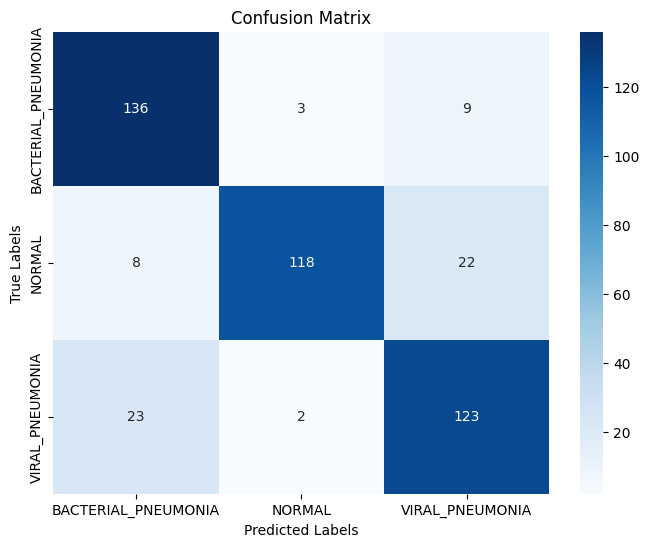

In [30]:
# Evaluate the trained model to display a per-class accuracy report and a confusion matrix.
helper_utils.per_class_acc_and_conf_matrix(trained_model, dm)

<a name='5-2'></a>
### 5.2 - Visualización de Predicciones

Tu análisis es más completo cuando observas cómo se comporta tu modelo con imágenes individuales. Echa un vistazo a algunas de las predicciones que realiza tu modelo sobre el conjunto de validación.



* Ejecuta la función `display_random_predictions`, la cual hace uso del conjunto de datos de validación del `DataModule` `dm`. Cada ejecución elegirá un lote aleatorio de imágenes para mostrar.

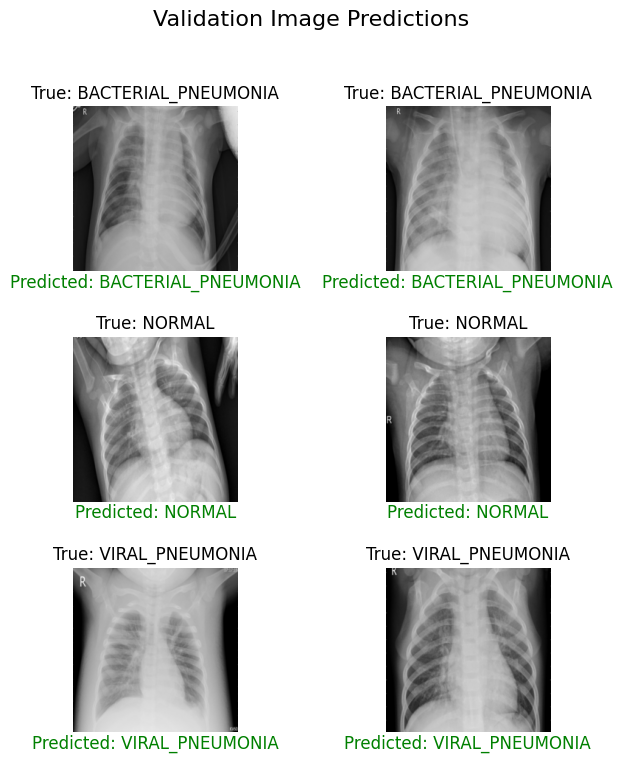

In [32]:
helper_utils.display_random_predictions(trained_model, dm)

<a name='5-3'></a>
### 5.3 - Una Prueba Real

Ahora, pasemos a una prueba real de las predicciones de tu modelo. Algunas imágenes fueron extraídas del conjunto de datos original y guardadas como un grupo verdaderamente "no visto" (unseen). Esto significa que tu modelo nunca ha tenido ningún contacto con estas imágenes durante el entrenamiento o la validación.

Estas imágenes están disponibles en las siguientes rutas:

* **BACTERIAL_PNEUMONIA (Neumonía Bacteriana)**
    * "./unseen/BACTERIAL_PNEUMONIA/person296_bacteria_1394.jpeg" 
    * "./unseen/BACTERIAL_PNEUMONIA/person441_bacteria_1916.jpeg" 
    * "./unseen/BACTERIAL_PNEUMONIA/person564_bacteria_2342.jpeg" 
* **NORMAL**
    * "./unseen/NORMAL/IM-0353-0001.jpeg" 
    * "./unseen/NORMAL/IM-0633-0001.jpeg" 
    * "./unseen/NORMAL/NORMAL2-IM-0866-0001.jpeg" 
* **VIRAL_PNEUMONIA (Neumonía Viral)**
    * "./unseen/VIRAL_PNEUMONIA/person1369_virus_2356.jpeg" 
    * "./unseen/VIRAL_PNEUMONIA/person1465_virus_2537.jpeg" 
    * "./unseen/VIRAL_PNEUMONIA/person1537_virus_2674.jpeg" 



Utiliza la función `display_prediction` para ver qué tan bien se desempeña tu modelo entrenado con estas imágenes.

* Siéntete libre de configurar el `image_path` con cualquiera de estas rutas de imagen.

In [33]:
# EDITABLE CELL

# Define the file path for the unseen image to be predicted.
image_path = "./unseen/BACTERIAL_PNEUMONIA/person296_bacteria_1394.jpeg"

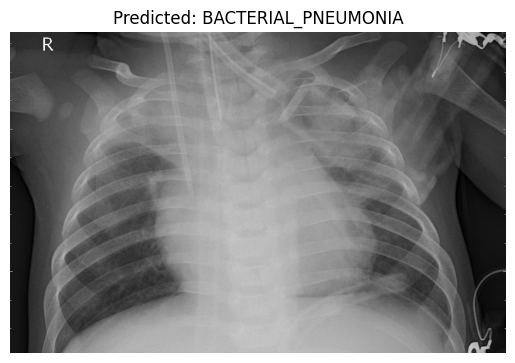

In [34]:
# Use the display_prediction function to show the image and its predicted class.
helper_utils.display_prediction(trained_model, dm, image_path)

## Conclusión

¡Excelente trabajo al completar esta tarea! Has navegado con éxito por el proceso de construcción de un sistema completo de aprendizaje profundo para el análisis de imágenes médicas. Al aplicar tus conocimientos de PyTorch y Lightning, has diseñado el motor central para un asistente de diagnóstico de neumonía, convirtiendo conceptos teóricos en una aplicación práctica y significativa.



Comenzaste esta tarea con la misión de resolver un problema del mundo real y lo has logrado creando un clasificador bien organizado y eficaz. Las habilidades que practicaste aquí, especialmente la estructuración de tu proyecto con el `DataModule` y el `LightningModule`, son vitales para construir sistemas de IA escalables y fáciles de mantener en cualquier entorno profesional. Debes sentir orgullo por la sofisticada herramienta que has construido. Sigue aprovechando estas habilidades para enfrentar desafíos nuevos y emocionantes.